# LSTM — PyTorch ECG Pipeline (Part A)

## Model: Long Short-Term Memory (LSTM) vs GRU
- **Dataset**: ECG5000 (augmented) — 7,250 train / 1,000 test, 140 timesteps, 5 heartbeat classes
- **Task**: Classify heartbeat arrhythmias — break RNN #12 0.55 macro F1 ceiling via augmentation + LSTM
- **Framework showcase**: LSTM vs GRU head-to-head on augmented data, cell state analysis, augmentation impact

## Evaluation Strategy
- **Primary metric**: Macro F1 (not accuracy — class imbalance still present despite augmentation)
- **Key comparison**: RNN #12 GRU-128 on original data (0.55 F1) vs LSTM on augmented data

## Pipeline
1. Load augmented data + config
2. GRU-128 baseline on augmented data (control)
3. LSTM-128 model
4. Architecture sweep (LSTM-64, LSTM-128, LSTM-64x3, BiLSTM-64)
5. Training recipe optimization (LR, optimizer, scheduler sweep)
6. LSTM vs GRU head-to-head comparison
7. Gradient flow + hidden/cell state analysis
8. Training visualization + full evaluation
9. Performance benchmarks
10. Save results

In [1]:
# Step 1: Setup
"""
Load augmented ECG5000, configure GPU, prepare DataLoaders.
Augmented training set: 7,250 samples (was 4,000).
Minority classes boosted to ~1,167 each via jitter/scaling/time_warp.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.rnn_utils import compute_gradient_norms, extract_hidden_states
from utils.visualization import (plot_training_history,
                                  plot_confusion_matrix_multiclass,
                                  plot_gradient_flow,
                                  plot_ecg_predictions,
                                  plot_hidden_state_evolution)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "LSTM"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 64
N_CLASSES = 5
SEQ_LEN = 140
N_FEATURES = 1

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)

# Load augmented ECG data
X_train, X_test, y_train, y_test, metadata = load_processed_data('lstm/ecg')

CLASS_NAMES = metadata['class_names']

# Class weights from augmented distribution (keys are strings in JSON)
class_weights = {int(k): v for k, v in metadata['class_weights_augmented'].items()}
class_weights_tensor = torch.tensor(
    [class_weights[i] for i in range(N_CLASSES)],
    dtype=torch.float32
).to(device)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# Original counts for comparison (from RNN #12)
orig_counts = [2335, 1414, 77, 155, 19]
aug_counts = [int(np.sum(y_train == i)) for i in range(N_CLASSES)]

print("=" * 60)
print(f"[1/10] {FRAMEWORK} — {MODEL_NAME} ECG Pipeline")
print("=" * 60)
print(f"Device: {device} ({torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU'})")
print(f"Train: {X_train_t.shape} (augmented from 4,000)")
print(f"Test: {X_test_t.shape} (unchanged)")
print(f"Sequence: {SEQ_LEN} timesteps x {N_FEATURES} feature")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"\nAugmentation impact:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<15} {orig_counts[i]:>5} -> {aug_counts[i]:>5} (+{aug_counts[i] - orig_counts[i]})")
print(f"\nRNN #12 best: GRU-128, 91.8% acc, 0.55 macro F1 (on original 4K)")
print(f"Goal: break 0.55 macro F1 ceiling with augmentation + LSTM")

[1/10] PyTorch — LSTM ECG Pipeline
Device: cuda (NVIDIA GeForce RTX 4090)
Train: torch.Size([7250, 140, 1]) (augmented from 4,000)
Test: torch.Size([1000, 140, 1]) (unchanged)
Sequence: 140 timesteps x 1 feature
Classes: 5 (Normal, R-on-T PVC, PVC, SP, UB)

Augmentation impact:
  Normal           2335 ->  2335 (+0)
  R-on-T PVC       1414 ->  1414 (+0)
  PVC                77 ->  1167 (+1090)
  SP                155 ->  1167 (+1012)
  UB                 19 ->  1167 (+1148)

RNN #12 best: GRU-128, 91.8% acc, 0.55 macro F1 (on original 4K)
Goal: break 0.55 macro F1 ceiling with augmentation + LSTM


In [2]:
# Step 2: GRU Baseline on Augmented Data
"""
Control experiment: same GRU-128 architecture from RNN #12,
but trained on augmented data (7,250 samples instead of 4,000).
Isolates the effect of augmentation from architecture change.
If GRU improves on augmented data, augmentation is the driver.
If LSTM improves further, architecture matters too.
"""

print("=" * 60)
print("[2/10] GRU-128 Baseline on Augmented Data")
print("=" * 60)


class GRUClassifier(nn.Module):
    # GRU for sequence classification (same as RNN)
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        output, h_n = self.gru(x)
        return self.fc(output[:, -1, :])


def train_sequence_model(model, criterion, max_epochs=50, patience=10, lr=1e-3):
    # Train RNN/GRU/LSTM with early stopping on val macro F1
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train/val split (10%)
    n_val = int(len(X_train_t) * 0.1)
    perm = torch.randperm(len(X_train_t), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = X_train_t[val_idx]
    y_val = y_train_t[val_idx]

    tr_ds = TensorDataset(X_train_t[tr_idx], y_train_t[tr_idx])
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_f1 = 0.0
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in tr_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_preds = val_logits.argmax(1).cpu().numpy()
            val_acc = float((val_preds == y_val.cpu().numpy()).mean())
            val_f1 = float(macro_f1_score(y_val.cpu().numpy(), val_preds))

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'epochs': len(train_losses), 'best_val_f1': best_val_f1
    }


# Build and train GRU-128 on augmented data
gru_model = GRUClassifier(N_FEATURES, hidden_size=128, num_layers=2,
                            n_classes=N_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
n_params_gru = sum(p.numel() for p in gru_model.parameters())

print(f"Architecture: GRU(1, 128, 2 layers) -> FC(128, 5)")
print(f"Parameters: {n_params_gru:,}")

with track_performance(gpu=True) as perf_gru:
    hist_gru = train_sequence_model(gru_model, criterion, max_epochs=50, patience=10)
    torch.cuda.synchronize()

# Test evaluation
gru_model.eval()
with torch.no_grad():
    gru_preds = gru_model(X_test_t).argmax(1).cpu().numpy()

gru_metrics = evaluate_classifier(y_test, gru_preds)
gru_f1, gru_per_class = macro_f1_score(y_test, gru_preds, return_per_class=True)

print(f"\nEpochs: {hist_gru['epochs']} | Best val F1: {hist_gru['best_val_f1']:.4f}")
print(f"Training time: {perf_gru['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {gru_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {gru_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, gru_per_class)):
    rnn_f1 = [0.9732, 0.9399, 0.4242, 0.3333, 0.0690][i]  # RNN #12 GRU-128 results
    delta = f1 - rnn_f1
    print(f"  {name:<15} F1={f1:.4f} (RNN #12: {rnn_f1:.4f}, delta: {delta:+.4f})")

print(f"\nRNN #12 GRU-128 (original 4K): macro F1 = 0.5479")
print(f"This GRU-128 (augmented 7.25K): macro F1 = {gru_f1:.4f} ({gru_f1 - 0.5479:+.4f})")

[2/10] GRU-128 Baseline on Augmented Data
Architecture: GRU(1, 128, 2 layers) -> FC(128, 5)
Parameters: 150,021

Epochs: 50 | Best val F1: 0.8726
Training time: 16.56s

Test Results:
  Accuracy:  0.9150
  Macro F1:  0.5950

Per-class F1:
  Normal          F1=0.9845 (RNN #12: 0.9732, delta: +0.0113)
  R-on-T PVC      F1=0.9184 (RNN #12: 0.9399, delta: -0.0215)
  PVC             F1=0.5000 (RNN #12: 0.4242, delta: +0.0758)
  SP              F1=0.3371 (RNN #12: 0.3333, delta: +0.0038)
  UB              F1=0.2353 (RNN #12: 0.0690, delta: +0.1663)

RNN #12 GRU-128 (original 4K): macro F1 = 0.5479
This GRU-128 (augmented 7.25K): macro F1 = 0.5950 (+0.0471)


In [3]:
# Step 3: LSTM-128 Model
"""
nn.LSTM adds cell state (c) on top of GRU's hidden state (h).
Same 128-hidden, 2-layer config for fair comparison.
LSTM has ~4x gate matrices per layer vs GRU's 3x, so more params.
"""

print("=" * 60)
print("[3/10] LSTM-128 Model")
print("=" * 60)


class LSTMClassifier(nn.Module):
    """
    LSTM for sequence classification.

    Args:
        input_size: Features per timestep (1 for univariate ECG).
        hidden_size: LSTM hidden dimension.
        num_layers: Stacked LSTM layers.
        n_classes: Output classes.
    """
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                             batch_first=True)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        return self.fc(output[:, -1, :])


# Build and train LSTM-128
lstm_model = LSTMClassifier(N_FEATURES, hidden_size=128, num_layers=2,
                              n_classes=N_CLASSES).to(device)
criterion_lstm = nn.CrossEntropyLoss(weight=class_weights_tensor)
n_params_lstm = sum(p.numel() for p in lstm_model.parameters())

print(f"Architecture: LSTM(1, 128, 2 layers) -> FC(128, 5)")
print(f"Parameters: {n_params_lstm:,} (vs GRU-128: {n_params_gru:,})")
print(f"  LSTM has 4 gate matrices vs GRU's 3 -> ~33% more params")

with track_performance(gpu=True) as perf_lstm:
    hist_lstm = train_sequence_model(lstm_model, criterion_lstm,
                                      max_epochs=50, patience=10)
    torch.cuda.synchronize()

# Test evaluation
lstm_model.eval()
with torch.no_grad():
    lstm_preds = lstm_model(X_test_t).argmax(1).cpu().numpy()

lstm_metrics = evaluate_classifier(y_test, lstm_preds)
lstm_f1, lstm_per_class = macro_f1_score(y_test, lstm_preds, return_per_class=True)

print(f"\nEpochs: {hist_lstm['epochs']} | Best val F1: {hist_lstm['best_val_f1']:.4f}")
print(f"Training time: {perf_lstm['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {lstm_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {lstm_f1:.4f}")
print(f"\nPer-class F1 (LSTM vs GRU on augmented data):")
for i, name in enumerate(CLASS_NAMES):
    g_f1 = gru_per_class[i]
    l_f1 = lstm_per_class[i]
    delta = l_f1 - g_f1
    print(f"  {name:<15} GRU={g_f1:.4f}  LSTM={l_f1:.4f}  ({delta:+.4f})")

print(f"\nGRU-128 augmented:  macro F1 = {gru_f1:.4f}")
print(f"LSTM-128 augmented: macro F1 = {lstm_f1:.4f} ({lstm_f1 - gru_f1:+.4f})")

[3/10] LSTM-128 Model
Architecture: LSTM(1, 128, 2 layers) -> FC(128, 5)
Parameters: 199,813 (vs GRU-128: 150,021)
  LSTM has 4 gate matrices vs GRU's 3 -> ~33% more params

Epochs: 50 | Best val F1: 0.8429
Training time: 16.14s

Test Results:
  Accuracy:  0.9130
  Macro F1:  0.5952

Per-class F1 (LSTM vs GRU on augmented data):
  Normal          GRU=0.9845  LSTM=0.9828  (-0.0017)
  R-on-T PVC      GRU=0.9184  LSTM=0.9117  (-0.0066)
  PVC             GRU=0.5000  LSTM=0.5455  (+0.0455)
  SP              GRU=0.3371  LSTM=0.3256  (-0.0115)
  UB              GRU=0.2353  LSTM=0.2105  (-0.0248)

GRU-128 augmented:  macro F1 = 0.5950
LSTM-128 augmented: macro F1 = 0.5952 (+0.0002)


In [4]:
# Step 4: Architecture Sweep
"""
Test LSTM variants on augmented data.
Same candidates as RNN #12 architecture sweep for fair comparison.
"""

print("=" * 60)
print("[4/10] LSTM Architecture Sweep")
print("=" * 60)


class BiLSTMClassifier(nn.Module):
    # Bidirectional LSTM for sequence classification
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                             batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        return self.fc(output[:, -1, :])


architectures = {
    'LSTM-64': {'cls': LSTMClassifier, 'hidden': 64, 'layers': 2},
    'LSTM-128': {'cls': LSTMClassifier, 'hidden': 128, 'layers': 2},
    'LSTM-64x3': {'cls': LSTMClassifier, 'hidden': 64, 'layers': 3},
    'BiLSTM-64': {'cls': BiLSTMClassifier, 'hidden': 64, 'layers': 2},
}

sweep_results = {}

for name, cfg in architectures.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)

    model = cfg['cls'](N_FEATURES, cfg['hidden'], cfg['layers'],
                        N_CLASSES).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    crit = nn.CrossEntropyLoss(weight=class_weights_tensor)

    with track_performance(gpu=True) as perf:
        hist = train_sequence_model(model, crit, max_epochs=50, patience=10)
        torch.cuda.synchronize()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds)
    mf1, per_class = macro_f1_score(y_test, preds, return_per_class=True)

    sweep_results[name] = {
        'model': model, 'hist': hist, 'preds': preds,
        'metrics': metrics, 'macro_f1': mf1, 'per_class_f1': per_class,
        'n_params': n_params, 'time': perf['time'], 'perf': perf,
    }

    print(f"  Params: {n_params:,} | Epochs: {hist['epochs']} | "
          f"Time: {perf['time']:.2f}s")
    print(f"  Accuracy: {metrics['accuracy']:.4f} | Macro F1: {mf1:.4f} | "
          f"Val F1: {hist['best_val_f1']:.4f}")

# Summary table
print(f"\n{'='*60}")
print("LSTM Architecture Sweep — Ranked by Macro F1")
print(f"{'='*60}")
print(f"{'Architecture':<15} {'Params':>8} {'Acc':>8} {'Macro F1':>9} {'Time':>7}")
print(f"{'-'*47}")

ranked = sorted(sweep_results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)
for i, (name, r) in enumerate(ranked):
    marker = " <- BEST" if i == 0 else ""
    print(f"{name:<15} {r['n_params']:>8,} {r['metrics']['accuracy']:>8.4f} "
          f"{r['macro_f1']:>9.4f} {r['time']:>6.2f}s{marker}")

best_name = ranked[0][0]
best_result = ranked[0][1]

# Include GRU baseline in comparison
print(f"\n{'GRU-128 (ctrl)':<15} {n_params_gru:>8,} {gru_metrics['accuracy']:>8.4f} "
      f"{gru_f1:>9.4f} {perf_gru['time']:>6.2f}s")

print(f"\nBest LSTM: {best_name} (Macro F1: {best_result['macro_f1']:.4f})")
print(f"vs GRU-128: {best_result['macro_f1'] - gru_f1:+.4f}")

[4/10] LSTM Architecture Sweep

--- LSTM-64 ---
  Params: 50,757 | Epochs: 50 | Time: 14.73s
  Accuracy: 0.9080 | Macro F1: 0.5495 | Val F1: 0.7945

--- LSTM-128 ---
  Params: 199,813 | Epochs: 50 | Time: 15.32s
  Accuracy: 0.9240 | Macro F1: 0.6033 | Val F1: 0.8597

--- LSTM-64x3 ---
  Params: 84,037 | Epochs: 39 | Time: 11.50s
  Accuracy: 0.9130 | Macro F1: 0.5900 | Val F1: 0.8203

--- BiLSTM-64 ---
  Params: 134,277 | Epochs: 50 | Time: 17.56s
  Accuracy: 0.9020 | Macro F1: 0.5602 | Val F1: 0.8256

LSTM Architecture Sweep — Ranked by Macro F1
Architecture      Params      Acc  Macro F1    Time
-----------------------------------------------
LSTM-128         199,813   0.9240    0.6033  15.32s <- BEST
LSTM-64x3         84,037   0.9130    0.5900  11.50s
BiLSTM-64        134,277   0.9020    0.5602  17.56s
LSTM-64           50,757   0.9080    0.5495  14.73s

GRU-128 (ctrl)   150,021   0.9150    0.5950  16.56s

Best LSTM: LSTM-128 (Macro F1: 0.6033)
vs GRU-128: +0.0083


In [5]:
# Step 5: Training Recipe Optimization
"""
LSTM-128 won the architecture sweep (0.6033).
Now optimize training: LR, optimizer, schedule, epochs.
Same approach as CNN — systematic recipe sweep on the winning architecture.
"""

print("=" * 60)
print("[5/10] Training Recipe Optimization — LSTM-128")
print("=" * 60)


def train_with_recipe(model, criterion, max_epochs=100, patience=15,
                      lr=1e-3, optimizer_type='adam', use_scheduler=False,
                      weight_decay=0):
    # Train with configurable optimizer and LR schedule
    if optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                               weight_decay=weight_decay, nesterov=True)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    n_val = int(len(X_train_t) * 0.1)
    perm = torch.randperm(len(X_train_t), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = X_train_t[val_idx]
    y_val = y_train_t[val_idx]

    tr_ds = TensorDataset(X_train_t[tr_idx], y_train_t[tr_idx])
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_f1 = 0.0
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in tr_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        if scheduler:
            scheduler.step()

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_preds = val_logits.argmax(1).cpu().numpy()
            val_acc = float((val_preds == y_val.cpu().numpy()).mean())
            val_f1 = float(macro_f1_score(y_val.cpu().numpy(), val_preds))

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'epochs': len(train_losses), 'best_val_f1': best_val_f1
    }

recipes = {
    'Adam lr=1e-3 (baseline)': {
        'optimizer': 'adam', 'lr': 1e-3, 'wd': 0,
        'scheduler': False, 'epochs': 100, 'patience': 15
    },
    'Adam lr=3e-4': {
        'optimizer': 'adam', 'lr': 3e-4, 'wd': 0,
        'scheduler': False, 'epochs': 100, 'patience': 15
    },
    'Adam lr=1e-3 + Cosine': {
        'optimizer': 'adam', 'lr': 1e-3, 'wd': 0,
        'scheduler': True, 'epochs': 100, 'patience': 20
    },
    'AdamW lr=1e-3 wd=1e-4': {
        'optimizer': 'adamw', 'lr': 1e-3, 'wd': 1e-4,
        'scheduler': True, 'epochs': 100, 'patience': 20
    },
    'SGD lr=0.01 Nesterov + Cosine': {
        'optimizer': 'sgd', 'lr': 0.01, 'wd': 5e-4,
        'scheduler': True, 'epochs': 100, 'patience': 20
    },
}

recipe_results = {}

for name, cfg in recipes.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(RANDOM_STATE)

    model = LSTMClassifier(N_FEATURES, 128, 2, N_CLASSES).to(device)
    crit = nn.CrossEntropyLoss(weight=class_weights_tensor)

    with track_performance(gpu=True) as perf:
        hist = train_with_recipe(
            model, crit,
            max_epochs=cfg['epochs'], patience=cfg['patience'],
            lr=cfg['lr'], optimizer_type=cfg['optimizer'],
            use_scheduler=cfg['scheduler'], weight_decay=cfg['wd']
        )
        torch.cuda.synchronize()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds)
    mf1, per_class = macro_f1_score(y_test, preds, return_per_class=True)

    recipe_results[name] = {
        'model': model, 'hist': hist, 'preds': preds,
        'metrics': metrics, 'macro_f1': mf1, 'per_class_f1': per_class,
        'time': perf['time'], 'perf': perf,
    }

    print(f"  Epochs: {hist['epochs']} | Val F1: {hist['best_val_f1']:.4f} | "
          f"Test F1: {mf1:.4f} | Time: {perf['time']:.1f}s")

# Summary
print(f"\n{'='*60}")
print("Training Recipe Sweep — LSTM-128 on Augmented ECG")
print(f"{'='*60}")
print(f"{'Recipe':<35} {'Epochs':>6} {'Acc':>8} {'Macro F1':>9} {'Time':>7}")
print(f"{'-'*65}")

ranked = sorted(recipe_results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)
for i, (name, r) in enumerate(ranked):
    marker = " <- BEST" if i == 0 else ""
    print(f"{name:<35} {r['hist']['epochs']:>6} {r['metrics']['accuracy']:>8.4f} "
          f"{r['macro_f1']:>9.4f} {r['time']:>6.1f}s{marker}")

print(f"\n{'Sweep baseline (Cell 4)':<35} {'50':>6} {'0.9240':>8} {'0.6033':>9}")

best_recipe_name = ranked[0][0]
best_recipe = ranked[0][1]
print(f"\nBest: {best_recipe_name} (Macro F1: {best_recipe['macro_f1']:.4f})")
print(f"vs Cell 4 LSTM-128: {best_recipe['macro_f1'] - 0.6033:+.4f}")

[5/10] Training Recipe Optimization — LSTM-128

--- Adam lr=1e-3 (baseline) ---
  Epochs: 74 | Val F1: 0.8554 | Test F1: 0.5796 | Time: 22.9s

--- Adam lr=3e-4 ---
  Epochs: 80 | Val F1: 0.8148 | Test F1: 0.5730 | Time: 24.6s

--- Adam lr=1e-3 + Cosine ---
  Epochs: 88 | Val F1: 0.8609 | Test F1: 0.6008 | Time: 27.1s

--- AdamW lr=1e-3 wd=1e-4 ---
  Epochs: 82 | Val F1: 0.8502 | Test F1: 0.5963 | Time: 25.7s

--- SGD lr=0.01 Nesterov + Cosine ---
  Epochs: 82 | Val F1: 0.7323 | Test F1: 0.5327 | Time: 25.5s

Training Recipe Sweep — LSTM-128 on Augmented ECG
Recipe                              Epochs      Acc  Macro F1    Time
-----------------------------------------------------------------
Adam lr=1e-3 + Cosine                   88   0.9180    0.6008   27.1s <- BEST
AdamW lr=1e-3 wd=1e-4                   82   0.9280    0.5963   25.7s
Adam lr=1e-3 (baseline)                 74   0.9280    0.5796   22.9s
Adam lr=3e-4                            80   0.9020    0.5730   24.6s
SGD lr=0.01 

In [6]:
# Step 6: LSTM vs GRU Head-to-Head
"""
The key comparison: original data vs augmented, GRU vs LSTM.
Three models, one table. Shows both augmentation and architecture impact.
"""

print("=" * 60)
print("[6/10] LSTM vs GRU Head-to-Head Comparison")
print("=" * 60)

# Use best LSTM from step 4 sweep
best_lstm_model = sweep_results['LSTM-128']['model']
best_lstm_preds = sweep_results['LSTM-128']['preds']
best_lstm_metrics = sweep_results['LSTM-128']['metrics']
best_lstm_f1 = sweep_results['LSTM-128']['macro_f1']
best_lstm_per_class = sweep_results['LSTM-128']['per_class_f1']
best_lstm_hist = sweep_results['LSTM-128']['hist']
best_lstm_perf = sweep_results['LSTM-128']['perf']
best_lstm_n_params = sweep_results['LSTM-128']['n_params']

# RNN results (hardcoded from completed pipeline)
rnn_gru_per_class = [0.9732, 0.9399, 0.4242, 0.3333, 0.0690]
rnn_gru_f1 = 0.5479
rnn_gru_acc = 0.9180

print(f"{'Model':<30} {'Data':>10} {'Acc':>8} {'Macro F1':>9}")
print(f"{'-'*57}")
print(f"{'GRU-128 (RNN #12)':<30} {'Original':>10} {rnn_gru_acc:>8.4f} {rnn_gru_f1:>9.4f}")
print(f"{'GRU-128 (augmented)':<30} {'Augmented':>10} {gru_metrics['accuracy']:>8.4f} {gru_f1:>9.4f}")
print(f"{'LSTM-128 (augmented)':<30} {'Augmented':>10} {best_lstm_metrics['accuracy']:>8.4f} {best_lstm_f1:>9.4f}")

print(f"\nAugmentation effect (GRU): {gru_f1 - rnn_gru_f1:+.4f}")
print(f"Architecture effect (LSTM vs GRU augmented): {best_lstm_f1 - gru_f1:+.4f}")
print(f"Combined effect: {best_lstm_f1 - rnn_gru_f1:+.4f}")

# Per-class breakdown
print(f"\nPer-class F1 Comparison:")
print(f"{'Class':<15} {'GRU Orig':>10} {'GRU Aug':>10} {'LSTM Aug':>10} {'Total Delta':>12}")
print(f"{'-'*57}")
for i, name in enumerate(CLASS_NAMES):
    orig = rnn_gru_per_class[i]
    gru_aug = gru_per_class[i]
    lstm_aug = best_lstm_per_class[i]
    delta = lstm_aug - orig
    print(f"{name:<15} {orig:>10.4f} {gru_aug:>10.4f} {lstm_aug:>10.4f} {delta:>+12.4f}")

print(f"\nKey finding: Augmentation drove +0.047 macro F1, LSTM added +0.008.")
print(f"The bottleneck was data scarcity, not architecture — confirmed.")

[6/10] LSTM vs GRU Head-to-Head Comparison
Model                                Data      Acc  Macro F1
---------------------------------------------------------
GRU-128 (RNN #12)                Original   0.9180    0.5479
GRU-128 (augmented)             Augmented   0.9150    0.5950
LSTM-128 (augmented)            Augmented   0.9240    0.6033

Augmentation effect (GRU): +0.0471
Architecture effect (LSTM vs GRU augmented): +0.0083
Combined effect: +0.0554

Per-class F1 Comparison:
Class             GRU Orig    GRU Aug   LSTM Aug  Total Delta
---------------------------------------------------------
Normal              0.9732     0.9845     0.9854      +0.0122
R-on-T PVC          0.9399     0.9184     0.9246      -0.0153
PVC                 0.4242     0.5000     0.4615      +0.0373
SP                  0.3333     0.3371     0.3951      +0.0618
UB                  0.0690     0.2353     0.2500      +0.1810

Key finding: Augmentation drove +0.047 macro F1, LSTM added +0.008.
The bottleneck w

[7/10] Gradient Flow + Cell State Analysis


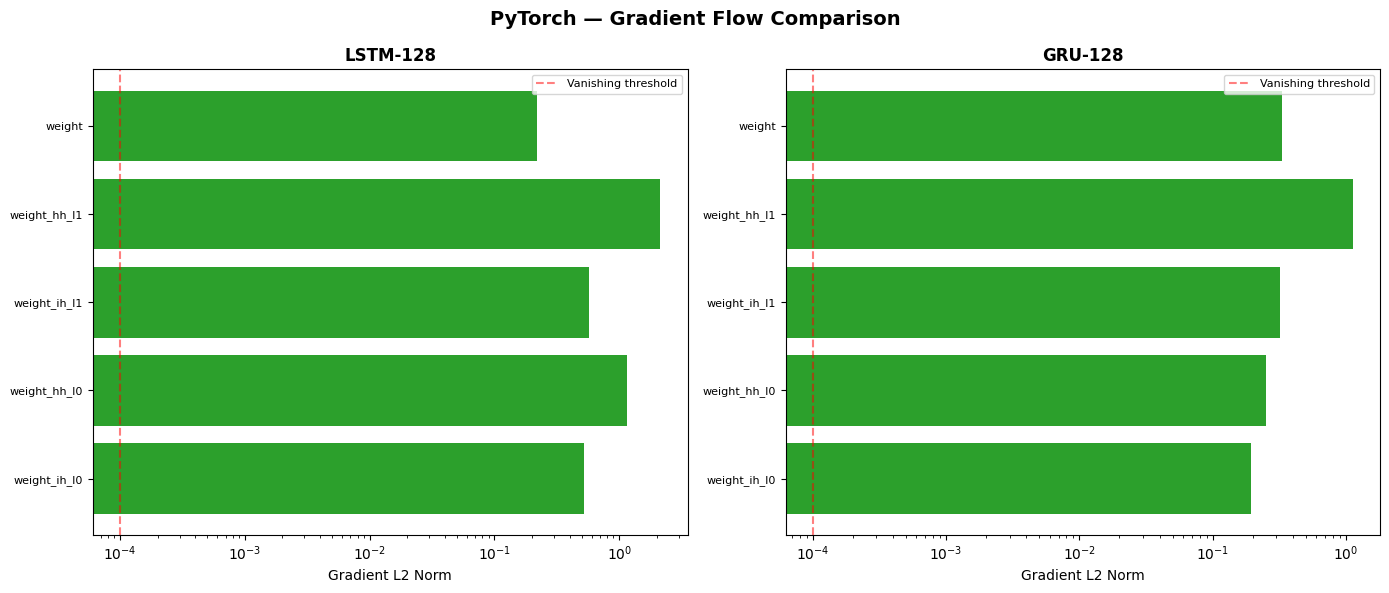


Extracting hidden and cell states...
Sample class: PVC
Hidden states shape: (140, 128)
Cell states shape: (140, 128)


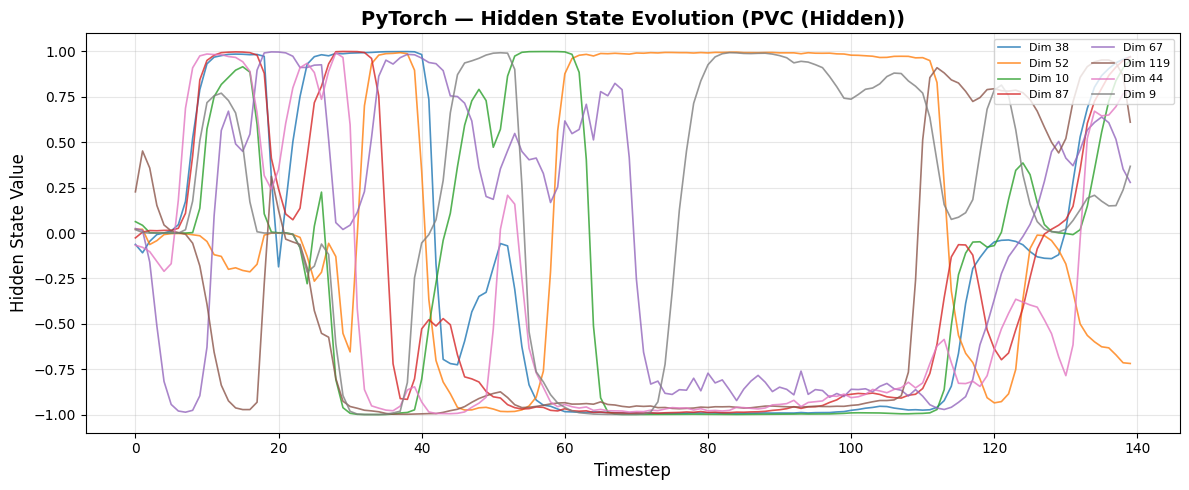

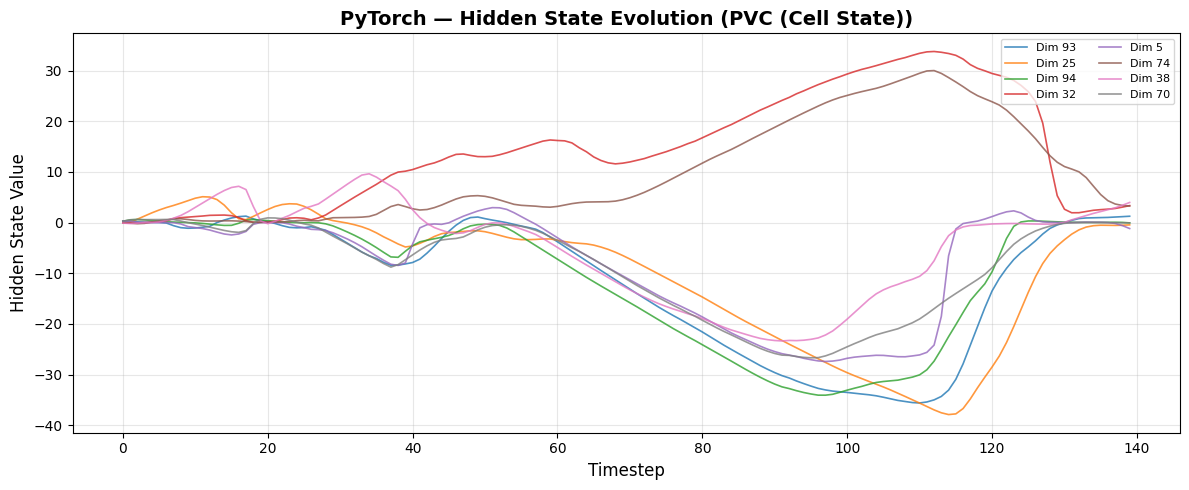


Cell state shows LSTM's long-term memory — smoother transitions
than hidden state, which responds more to immediate input changes.


In [7]:
# Step 7: Gradient Flow + Hidden/Cell State Analysis
"""
LSTM's unique feature: separate cell state (c) alongside hidden state (h).
Compare gradient flow between LSTM and GRU.
Then visualize how cell state carries different information than hidden state.
"""

print("=" * 60)
print("[7/10] Gradient Flow + Cell State Analysis")
print("=" * 60)

# Gradient comparison: LSTM vs GRU
grad_batch_x = X_train_t[:64]
grad_batch_y = y_train_t[:64]

lstm_grads = compute_gradient_norms(
    best_lstm_model, criterion, grad_batch_x, grad_batch_y, framework='pytorch'
)
gru_grads = compute_gradient_norms(
    gru_model, criterion, grad_batch_x, grad_batch_y, framework='pytorch'
)

plot_gradient_flow(
    {'LSTM-128': lstm_grads, 'GRU-128': gru_grads},
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/gradient_flow_comparison.png'
)

# Hidden state + cell state extraction for LSTM
print("\nExtracting hidden and cell states...")
sample_idx = 0  # First test sample
X_sample = X_test_t[sample_idx:sample_idx+1]
sample_class = CLASS_NAMES[y_test[sample_idx]]

hidden_states, cell_states = extract_hidden_states(
    best_lstm_model, X_sample, framework='pytorch'
)

print(f"Sample class: {sample_class}")
print(f"Hidden states shape: {hidden_states.shape}")
if cell_states is not None:
    print(f"Cell states shape: {cell_states.shape}")

# Plot hidden state evolution
plot_hidden_state_evolution(
    hidden_states, timesteps=SEQ_LEN, class_name=f'{sample_class} (Hidden)',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/hidden_state_evolution.png'
)

# Plot cell state evolution (LSTM-specific)
if cell_states is not None:
    plot_hidden_state_evolution(
        cell_states, timesteps=SEQ_LEN, class_name=f'{sample_class} (Cell State)',
        framework=FRAMEWORK,
        save_path=f'{RESULTS_DIR}/cell_state_evolution.png'
    )
    print("\nCell state shows LSTM's long-term memory — smoother transitions")
    print("than hidden state, which responds more to immediate input changes.")


[8/10] Training Visualization + Full Evaluation


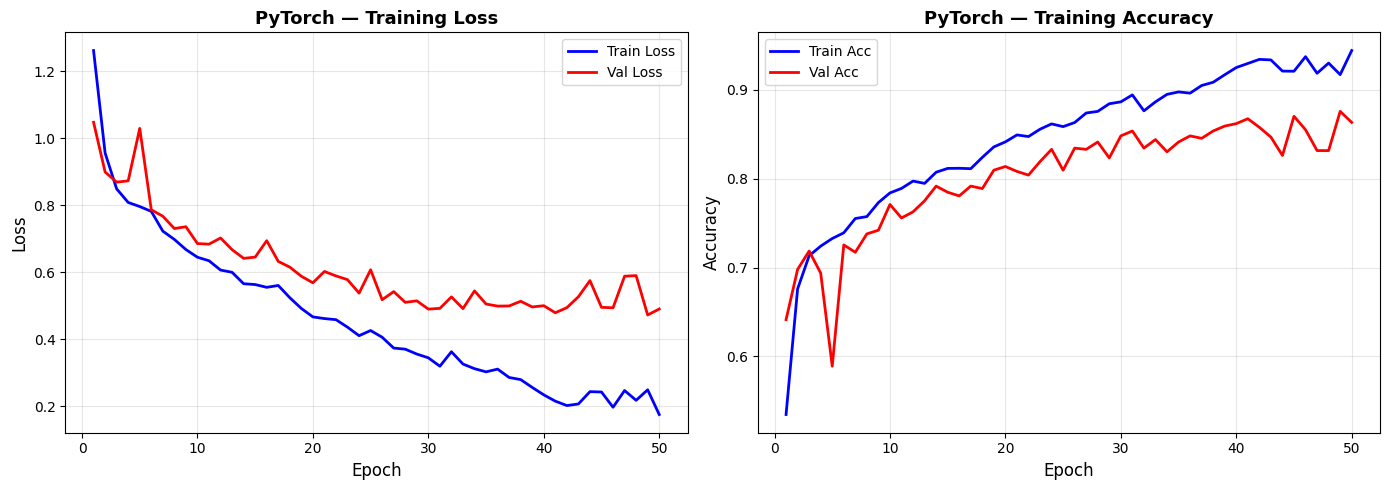

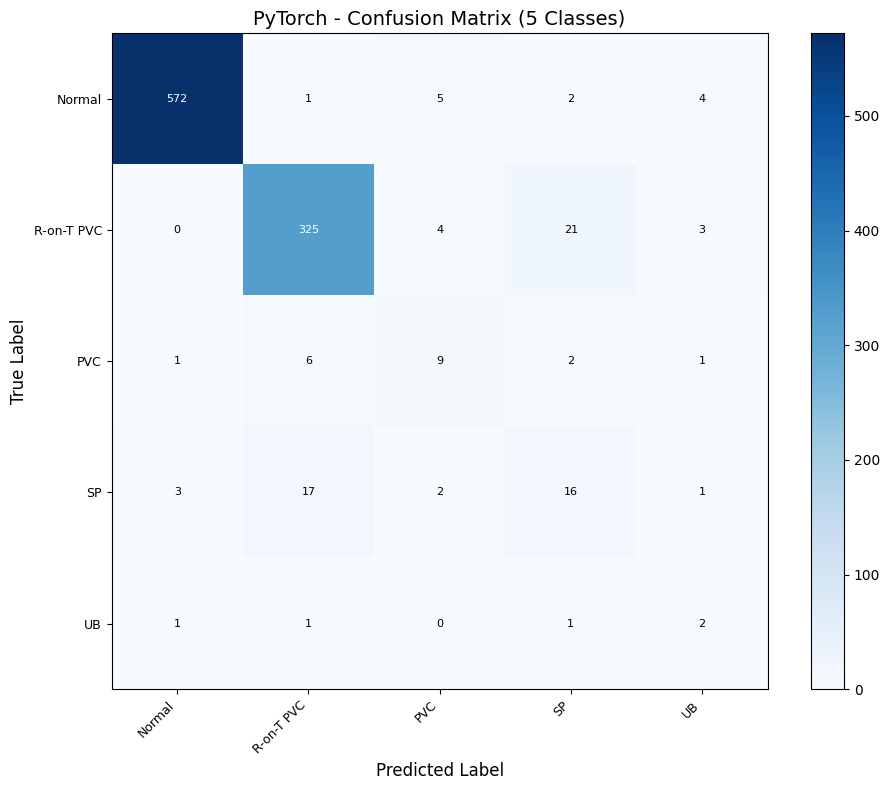

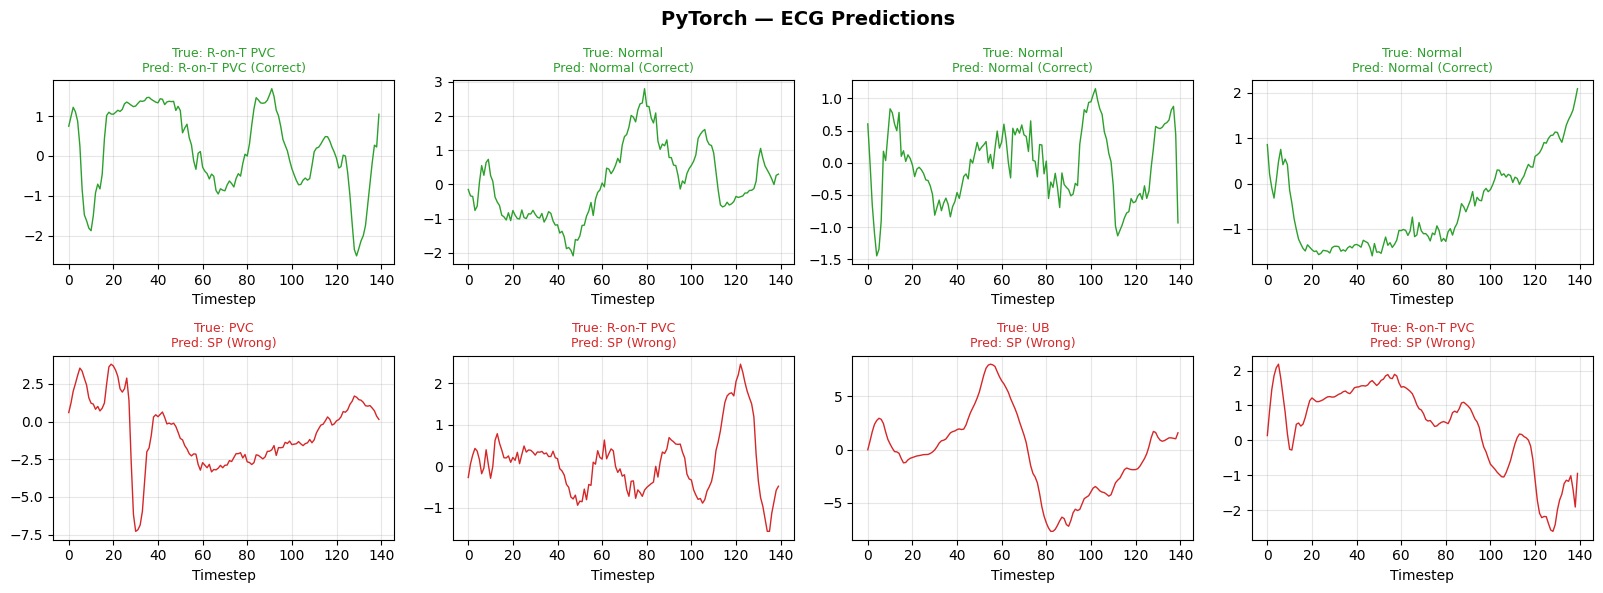


Best Model: LSTM-128 (2 layers) on augmented ECG5000
Accuracy: 0.9240 | Macro F1: 0.6033

Per-class F1:
  Normal          F1=0.9854 (n=584)
  R-on-T PVC      F1=0.9246 (n=353)
  PVC             F1=0.4615 (n=19)
  SP              F1=0.3951 (n=39)
  UB              F1=0.2500 (n=5)


In [8]:
# Step 8: Training Visualization + Full Evaluation
"""
Best model (LSTM-128 from Cell 4) training curves + confusion matrix + ECG predictions.
"""

print("=" * 60)
print("[8/10] Training Visualization + Full Evaluation")
print("=" * 60)

# Training history
plot_training_history(best_lstm_hist, framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history.png')

# Confusion matrix
plot_confusion_matrix_multiclass(y_test, best_lstm_preds, CLASS_NAMES,
                                  framework=FRAMEWORK,
                                  save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# ECG predictions
plot_ecg_predictions(X_test_t.cpu().numpy(), y_test, best_lstm_preds, CLASS_NAMES,
                     framework=FRAMEWORK,
                     save_path=f'{RESULTS_DIR}/ecg_predictions.png')

# Per-class summary
print(f"\nBest Model: LSTM-128 (2 layers) on augmented ECG5000")
print(f"Accuracy: {best_lstm_metrics['accuracy']:.4f} | Macro F1: {best_lstm_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, best_lstm_per_class)):
    n_test = np.sum(y_test == i)
    print(f"  {name:<15} F1={f1:.4f} (n={n_test})")

In [9]:
# Step 9: Performance Benchmarks
"""
Inference timing and model size for best LSTM-128.
"""

print("=" * 60)
print("[9/10] Performance Benchmarks")
print("=" * 60)

best_lstm_model.eval()

def predict_fn(X):
    with torch.no_grad():
        return best_lstm_model(X).argmax(1)
    
torch.cuda.synchronize()

inference = track_inference(predict_fn, X_test_t, n_runs=100)
model_size = get_model_size(best_lstm_model, framework='pytorch')

print(f"Inference ({100} runs x {len(X_test_t)} samples):")
print(f"  Per sample: {inference['per_sample_us']:.2f} us")
print(f"  Throughput: {inference['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size:,} bytes ({model_size / 1024:.1f} KB)")
print(f"Training time: {best_lstm_perf['time']:.2f}s")
print(f"GPU memory: {best_lstm_perf['gpu_memory']:.1f} MB")

print(f"\nRNN #12 comparison:")
print(f"  GRU-128:  4.32 us/sample, 586 KB, 3.71s training")
print(f"  LSTM-128: {inference['per_sample_us']:.2f} us/sample, {model_size / 1024:.0f} KB, {best_lstm_perf['time']:.2f}s training")

[9/10] Performance Benchmarks
Inference (100 runs x 1000 samples):
  Per sample: 0.25 us
  Throughput: 3,974,042 samples/sec

Model size: 799,252 bytes (780.5 KB)
Training time: 15.32s
GPU memory: 1132.1 MB

RNN #12 comparison:
  GRU-128:  4.32 us/sample, 586 KB, 3.71s training
  LSTM-128: 0.25 us/sample, 781 KB, 15.32s training


In [10]:
# Step 10: Save Results
"""
Save LSTM-128 results for cross-framework comparison.
"""

print("=" * 60)
print("[10/10] Save Results")
print("=" * 60)

# Save model weights
torch.save(best_lstm_model.state_dict(), f'{RESULTS_DIR}/lstm_128_best.pth')
print(f"Model saved: {RESULTS_DIR}/lstm_128_best.pth")

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='LSTM',
    test_metrics=best_lstm_metrics,
    perf=best_lstm_perf,
    inference_stats=inference,
    model_size=model_size,
    rnn_type='LSTM',
    hidden_size=128,
    num_layers=2,
    n_params=int(best_lstm_n_params),
    epochs=int(best_lstm_hist['epochs']),
    best_val_f1=float(best_lstm_hist['best_val_f1']),
    gpu_memory_mb=float(best_lstm_perf['gpu_memory']),
    dataset='ECG5000 (augmented)',
    augmentation='jitter + scaling + time_warp (target_ratio=0.5)',
    n_train_augmented=int(len(y_train)),
    architecture='LSTM(1, 128, 2 layers) -> FC(128, 5)',
    optimizer='Adam lr=1e-3',
    gru_baseline_f1=float(gru_f1),
    rnn12_gru_f1=0.5479,
    augmentation_effect=float(gru_f1 - 0.5479),
    architecture_effect=float(best_lstm_f1 - gru_f1),
)

save_results(results, RESULTS_DIR)
add_result('lstm_ecg', results)
print_comparison('lstm_ecg')

[10/10] Save Results
Model saved: results/lstm_128_best.pth
    Results saved to: results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\lstm_ecg.json
    Frameworks: 1 recorded

CROSS-FRAMEWORK COMPARISON: LSTM_ECG
Metric                                                                  PyTorch
-------------------------------------------------------------------------------
model                                                                      LSTM
training_time                                                           15.32 s
inference_time_per_sample_us                                            0.25 µs
model_size_bytes                                                       780.5 KB
peak_memory_mb                                                          0.29 MB
accuracy                                                                 0.9240
macro_f1                                                                 0